# Model Benchmarking (Coverage)

Train LSTM, DeepAR, and TFT on `data_1to7`, then fine-tune Chronos-2 on the same dataset. The summary reports coverage on train/val/test and plots the 0.8 one-step coverage target.


In [5]:
# Optional GPU setup (Colab)
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
HAS_CUDA = False
try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except Exception:
    pass

if IN_COLAB and HAS_CUDA:
    # Install dependencies only when running on Colab with GPU
    !pip -q install -U pip
    !pip -q install -r requirements.txt
    # Optional: verify GPU
    !nvidia-smi
else:
    print(f'GPU setup skipped (colab={IN_COLAB}, cuda={HAS_CUDA}).')


GPU setup skipped (colab=False, cuda=False).


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts.train_utils import train_all
from scripts.chronos2_finetune import (
    Chronos2FineTuneConfig,
    build_default_hyperparameters,
    load_splits_for_autogluon,
    run_chronos2_finetune,
    evaluate_chronos2_models,
)

MODEL_TYPES = ["lstm", "deepar", "tft"]
DATASET = "data_1to7"
SPLITS = ["train", "val", "test"]

CONTEXT_LENGTH = 64
FORECAST_LENGTH = 1
QUANTILES = (0.1, 0.5, 0.9)
MAX_EPOCHS = 100
PATIENCE = 3
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_HEADS = 4
COVERAGE_TARGET = 0.8

AUTOGLUON_TIME_LIMIT = 2000  # seconds
AUTOGLUON_EVAL_METRIC = "RMSE"
AUTOGLUON_FREQ = "S"  # 1-second cadence (dataset has irregular gaps)
AUTOGLUON_KNOWN_COVARIATES = []

RESULTS_DIR = Path("results/benchmarks")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHRONOS2_CONFIG = Chronos2FineTuneConfig(
    dataset_base=DATASET,
    prediction_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
    freq=AUTOGLUON_FREQ,
    eval_metric=AUTOGLUON_EVAL_METRIC,
    time_limit=AUTOGLUON_TIME_LIMIT,
    known_covariates_names=AUTOGLUON_KNOWN_COVARIATES,
    results_dir=RESULTS_DIR,
    hyperparameters=build_default_hyperparameters(),
    #hyperparameters={"Chronos2": {"fine_tune": True, "fine_tune_mode": "full", 
    #                              "fine_tune_lr": 1e-4, "fine_tune_steps": 2000, "fine_tune_batch_size": 32}},
)


## Train baseline models

This runs LSTM, DeepAR, and TFT on `data_1to7`. Coverage shown is the final epoch value returned by the trainer.


In [2]:
train_results, train_histories = train_all(
    MODEL_TYPES,
    DATASET,
    context_length=CONTEXT_LENGTH,
    forecast_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
)

train_rows = []
for (dataset, model), metrics in train_results.items():
    for split, coverage in metrics.items():
        train_rows.append(
            {"dataset": dataset, "split": split, "model": model, "coverage": coverage}
        )

train_df = pd.DataFrame(train_rows)
train_pivot = train_df.pivot_table(
    index=["dataset", "split"], columns="model", values="coverage"
).sort_index()
train_pivot


Epoch 1/100 - train_loss=0.465 - train_rmse=3.325 - val_loss=0.672 - val_rmse=4.522 - test_loss=0.780 - test_rmse=5.408 
Epoch 2/100 - train_loss=0.391 - train_rmse=2.889 - val_loss=0.639 - val_rmse=4.476 - test_loss=0.734 - test_rmse=5.217 
Epoch 3/100 - train_loss=0.381 - train_rmse=2.900 - val_loss=0.623 - val_rmse=4.506 - test_loss=0.717 - test_rmse=5.240 
Epoch 4/100 - train_loss=0.377 - train_rmse=2.882 - val_loss=0.636 - val_rmse=4.137 - test_loss=0.725 - test_rmse=4.847 
Epoch 5/100 - train_loss=0.375 - train_rmse=2.853 - val_loss=0.608 - val_rmse=4.300 - test_loss=0.697 - test_rmse=5.009 
Early stopping at epoch 6: train_rmse=2.821, val_rmse=4.327, test_rmse=4.984


'Final metrics'

,metric,value
0,train_loss,0.373
1,train_rmse,2.821
2,val_loss,0.609
3,val_rmse,4.327
4,train_q0.1,0.175
5,train_q0.5,0.673
6,train_q0.9,0.273
7,val_q0.1,0.291
8,val_q0.5,1.085
9,val_q0.9,0.460


Epoch 1/100 - train_loss=1.824 - train_rmse=2.697 - val_loss=2.265 - val_rmse=4.075 - test_loss=2.332 - test_rmse=4.784 
Epoch 2/100 - train_loss=1.686 - train_rmse=2.589 - val_loss=2.214 - val_rmse=4.042 - test_loss=2.294 - test_rmse=4.742 
Epoch 3/100 - train_loss=1.634 - train_rmse=2.501 - val_loss=2.133 - val_rmse=3.851 - test_loss=2.206 - test_rmse=4.435 
Epoch 4/100 - train_loss=1.604 - train_rmse=2.465 - val_loss=2.136 - val_rmse=3.881 - test_loss=2.193 - test_rmse=4.453 
Epoch 5/100 - train_loss=1.588 - train_rmse=2.447 - val_loss=2.141 - val_rmse=3.861 - test_loss=2.204 - test_rmse=4.410 
Epoch 6/100 - train_loss=1.590 - train_rmse=2.448 - val_loss=2.124 - val_rmse=3.884 - test_loss=2.182 - test_rmse=4.438 
Epoch 7/100 - train_loss=1.580 - train_rmse=2.437 - val_loss=2.114 - val_rmse=3.837 - test_loss=2.160 - test_rmse=4.385 
Epoch 8/100 - train_loss=1.576 - train_rmse=2.435 - val_loss=2.131 - val_rmse=3.833 - test_loss=2.186 - test_rmse=4.394 
Epoch 9/100 - train_loss=1.578 -

'Final metrics'

,metric,value
0,train_loss,1.566
1,train_rmse,2.415
2,val_loss,2.106
3,val_rmse,3.823
4,train_q0.1,0.248
5,train_q0.5,0.775
6,train_q0.9,0.302
7,val_q0.1,0.413
8,val_q0.5,1.295
9,val_q0.9,0.491


Epoch 1/100 - train_loss=0.426 - train_rmse=3.081 - val_loss=0.648 - val_rmse=4.739 - test_loss=0.755 - test_rmse=5.532 
Epoch 2/100 - train_loss=0.386 - train_rmse=2.932 - val_loss=0.609 - val_rmse=4.415 - test_loss=0.705 - test_rmse=5.203 
Epoch 3/100 - train_loss=0.373 - train_rmse=2.855 - val_loss=0.618 - val_rmse=4.347 - test_loss=0.703 - test_rmse=4.988 
Epoch 4/100 - train_loss=0.369 - train_rmse=2.856 - val_loss=0.603 - val_rmse=4.385 - test_loss=0.675 - test_rmse=4.933 
Early stopping at epoch 5: train_rmse=2.850, val_rmse=4.363, test_rmse=5.006


'Final metrics'

,metric,value
0,train_loss,0.367
1,train_rmse,2.850
2,val_loss,0.604
3,val_rmse,4.363
4,train_q0.1,0.175
5,train_q0.5,0.650
6,train_q0.9,0.277
7,val_q0.1,0.292
8,val_q0.5,1.055
9,val_q0.9,0.473


model              deepar      lstm       tft
dataset   split                              
data_1to7 test   0.882125  0.813269  0.808938
          train  0.851942  0.799548  0.799820
          val    0.878705  0.818741  0.840173

## AutoGluon Chronos-2 fine-tuning

We fine-tune Chronos-2 using AutoGluon TimeSeries with a zero-shot and fine-tuned run.


In [3]:
train_data, val_data, test_data, data_freq = load_splits_for_autogluon(CHRONOS2_CONFIG)

predictor, model_names, leaderboard = run_chronos2_finetune(
    CHRONOS2_CONFIG,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    freq=data_freq,
)

autogluon_df = evaluate_chronos2_models(
    predictor,
    model_names=model_names,
    splits={"train": train_data, "val": val_data, "test": test_data},
    dataset_label=DATASET,
    prediction_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
)

autogluon_coverage_pivot = autogluon_df.pivot_table(
    index=["dataset", "split"], columns="model", values="coverage"
).sort_index()
autogluon_rmse_pivot = autogluon_df.pivot_table(
    index=["dataset", "split"], columns="model", values="rmse"
).sort_index()

autogluon_coverage_pivot, autogluon_rmse_pivot, leaderboard


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/autogluon/timeseries/dataset/ts_dataframe.py:1076: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/autogluon/timeseries/dataset/ts_dataframe.py:1076: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/autogluon/timeseries/dataset/ts_dataframe.py:1076: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/autogluon/timeseries/predictor.py:197: FutureWarnin

(model            autogluon_Chronos2ZeroShot
 dataset   split                            
 data_1to7 test                     0.802326
           train                    0.860465
           val                      0.779070,
 model            autogluon_Chronos2ZeroShot
 dataset   split                            
 data_1to7 test                     5.358501
           train                    4.000034
           val                      4.938886,
               model  score_test  score_val  pred_time_test  pred_time_val  \
 0  Chronos2ZeroShot   -5.358501  -4.938886        8.226919        6.59379   
 
    fit_time_marginal  fit_order  
 0           1.394031          1  )

## Coverage and RMSE comparison summary

This table and plot compare coverage across train/val/test for all models.
The AutoGluon tables above include both coverage and RMSE for Chronos-2
ZeroShot vs FineTuned.


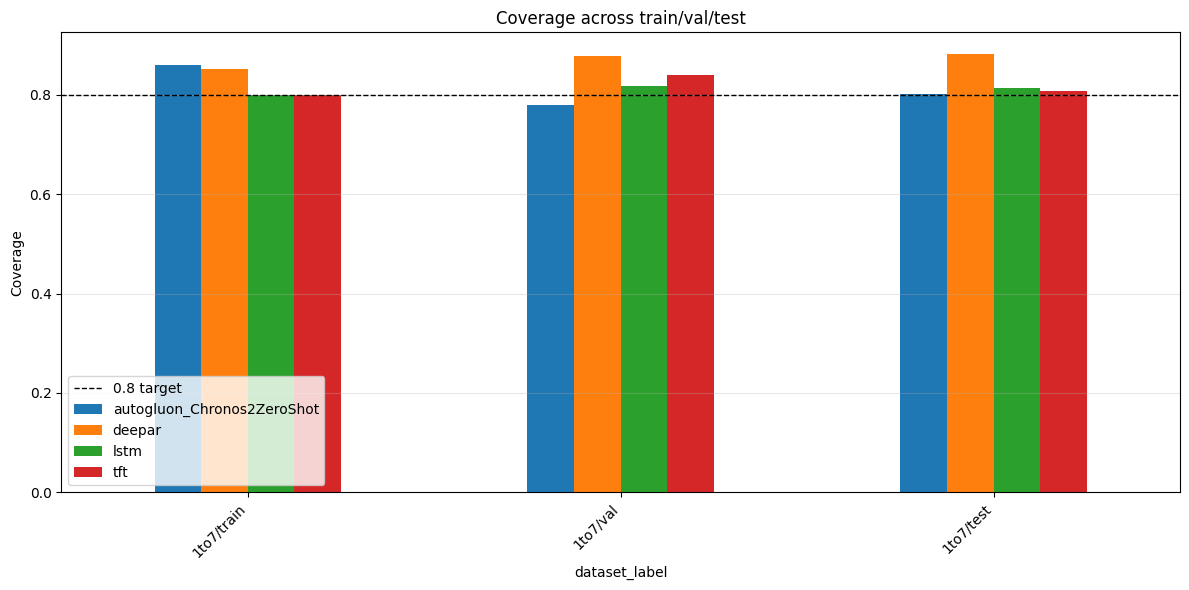

model            autogluon_Chronos2ZeroShot
dataset   split                            
data_1to7 test                     5.358501
          train                    4.000034
          val                      4.938886

In [4]:
summary_df = pd.concat(
    [train_df, autogluon_df[["dataset", "split", "model", "coverage"]]],
    ignore_index=True,
)
summary_df["dataset_label"] = summary_df["dataset"].str.replace("data_", "") + "/" + summary_df["split"]
order = [
    "1to7/train",
    "1to7/val",
    "1to7/test",
]

summary_pivot = summary_df.pivot_table(
    index="dataset_label", columns="model", values="coverage"
).reindex(order)
summary_pivot  # type: ignore

ax = summary_pivot.plot(kind="bar", figsize=(12, 6))
ax.axhline(COVERAGE_TARGET, color="black", linestyle="--", linewidth=1, label="0.8 target")
ax.set_ylabel("Coverage")
ax.set_title("Coverage across train/val/test")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

autogluon_rmse_pivot
